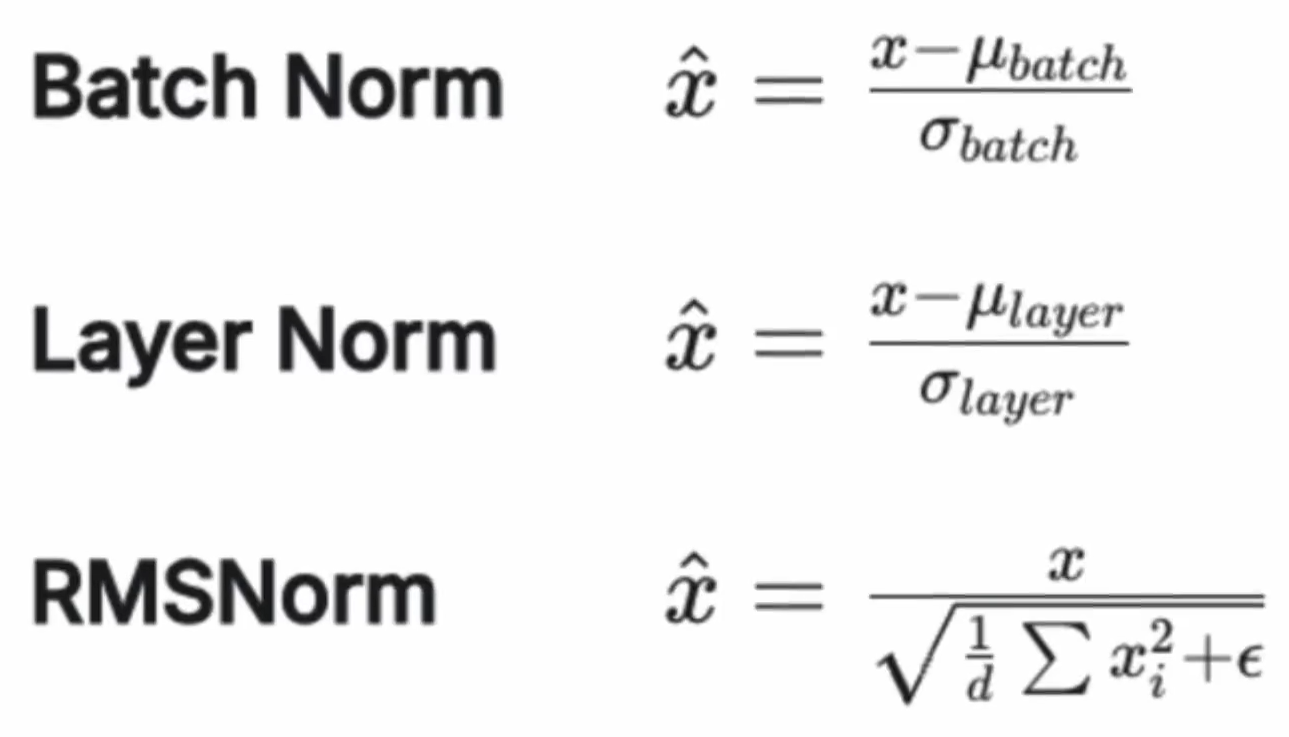

In [ ]:
import torch
import torch.nn as nn

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-9):
        super().__init__()
        self.eps = eps
        self.weight = nn.parameter(torch.ones(dim)) #只要学习权重不需要学习偏置

    def forward(self,x):
        Norm = x * torch.rsqrt(x.pow(2).mean(dim=-1,keepdim=True)+self.eps)  #平方和的均值开根（均方根）
        return self.weight * Norm


In [ ]:
import torch
import torch.nn as nn

class LayerNorm(nn.Module):#区别就在于有偏移量
    def __init__(self, dim, eps=1e-9):
        super().__init__()
        self.eps = eps
        self.weight = nn.parameter(torch.ones(dim))  
        self.bias = nn.parameter(torch.zeros(dim))  

    def forward(self,x):
        mean = x.mean(dim=-1,keepdims=True)
        var =  x.var(dim=-1,keepdims=True,unbaised=False)
        Norm = (x - mean)/torch.sqrt(var+self.eps)
        return self.weight * Norm + self.bias


In [ ]:
import torch
import torch.nn as nn

class BatchNorm(nn.Module):
    def __init__(self, dim, eps=1e-9,momentum=0.1):
        super().__init__()
        self.eps = eps
        self.momentum = momentum
        self.weight = nn.parameter(torch.ones(dim))  
        self.bais = nn.parameter(torch.zeros(dim))  

        self.register_buffer('running_mean',torch.zeros(dim))
        self.register_buffer('running_var',torch.ones(dim))
    
    def forward(self,x):
        if self.training:
            mean = x.mean(dim=0,keepdims=True) 
            var =  x.var(dim=0,keepdims=True,unbaised=False)

            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean +self.momentum *mean().squeeze()
                self.running_var = (1-self.momentum)*self.running_var +self.momentum *var().squeeze()
        else:
            mean = self.momentum *mean().squeeze(0)
            var = self.momentum *var().squeeze(0)
        Norm = (x - mean)/torch.sqrt(var+self.eps)
        return self.weight * Norm+ self.bias
        


C:\Users\95723\AppData\Local\Temp\ipykernel_33016\310067959.py:4: RuntimeWarning: overflow encountered in exp
  ex_fenzi= np.exp(x)
C:\Users\95723\AppData\Local\Temp\ipykernel_33016\310067959.py:7: RuntimeWarning: invalid value encountered in divide
  return ex_fenzi/ex_fenmu


array([nan, nan, nan])